# Experimento empírico: preservación de información en *cruces* de modelos de lenguaje



Esteban García Gaitán - Santiago Forero Rosales - Zaira Alejandra Forero Rojas  · UNAL

---

## Idea del experimento

En el informe, el factor de degradación $\alpha$ era un **parámetro libre** de la simulación.
Aquí lo **medimos empíricamente** entre cuatro modelos de lenguaje reales, y en vez de un lazo
recursivo sobre un mismo modelo ($A\to A$) estudiamos **todos los cruces** $A\to B$.



### Los cuatro modelos

| Etiqueta | HuggingFace ID | Params aprox. |
|---|---|---|
| `pythia70m` | `EleutherAI/pythia-70m` | 70 M |
| `distilgpt2` | `distilgpt2` | 82 M |
| `smollm2` | `HuggingFaceTB/SmolLM2-135M` | 135 M |
| `qwen0.5b` | `Qwen/Qwen2.5-0.5B` | 500 M |



### La medida de información (Shannon)

Cuando el modelo $A$ genera un texto $x$, la **cross-entropy** que un modelo $M$ le asigna es
$$H_M(x) = -\frac{1}{N}\sum_{i=1}^{N}\log P_M(x_i \mid x_{<i}),$$ Esta es la cantidad
shannoniana de información: si $M$ encuentra $x$ muy sorprendente, le cuesta más describirlo ⇒ perdió
información sobre la distribución que generó $x$.

### Factor de degradación del cruce $A\to B$

$$\boxed{\;\alpha_{A\to B} = \frac{H_A(x_A)}{H_B(x_A)} \in (0,1]\;}$$

donde $x_A$ es texto **generado por $A$**. $H_A(x_A)$ es la auto-entropía de $A$ (el mínimo posible
para su propio texto); $H_B(x_A)$ es lo que le cuesta a $B$ ese mismo texto. El cociente mide qué
fracción de la información de $A$ "sobrevive" al ser vista por $B$. Es **asimétrico** por construcción:
$H_A(x_A)/H_B(x_A) \neq H_B(x_B)/H_A(x_B)$.

### Conexión con la dinámica del proyecto

Cada $\alpha_{A\to B}$ medido se inyecta en la recurrencia escalar del informe
$$I_{t+1} = h + (1-h)\big[(1-f)\,\alpha_{A\to B}\,I_t + f\big]$$
y comparamos la trayectoria/calidad estacionaria $I^\star_{A\to B}$ de cada cruce. El cruce con
mayor $\alpha$ (y por tanto mayor $I^\star$) es el que **mejor preserva la información**.


In [ ]:
!pip install -q transformers accelerate datasets 2>/dev/null

import torch, numpy as np, os, json, itertools, time
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float16 if DEVICE == "cuda" else torch.float32
print("Dispositivo:", DEVICE, "| dtype:", DTYPE)

OUTDIR = "salidas_cruces_llm"
os.makedirs(OUTDIR, exist_ok=True)
def out(name): return os.path.join(OUTDIR, name)

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)

Dispositivo: cuda | dtype: torch.float16


In [ ]:
MODEL_IDS = {
    "pythia70m":  "EleutherAI/pythia-70m",
    "distilgpt2": "distilgpt2",
    "smollm2":    "HuggingFaceTB/SmolLM2-135M",
    "qwen0.5b":   "Qwen/Qwen2.5-0.5B",
}
NAMES = list(MODEL_IDS.keys())

def load_model(model_id):
    tok = AutoTokenizer.from_pretrained(model_id)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    mdl = AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=DTYPE).to(DEVICE)
    mdl.eval()
    return mdl, tok

MODELS = {}
for name, mid in MODEL_IDS.items():
    t0 = time.time()
    MODELS[name] = load_model(mid)
    print(f"  {name:11s} cargado ({mid}) en {time.time()-t0:.1f}s")
print("Todos los modelos listos.")

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

  pythia70m   cargado (EleutherAI/pythia-70m) en 1.1s


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

  distilgpt2  cargado (distilgpt2) en 1.2s


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

  smollm2     cargado (HuggingFaceTB/SmolLM2-135M) en 1.2s


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

  qwen0.5b    cargado (Qwen/Qwen2.5-0.5B) en 4.3s
Todos los modelos listos.


## 2. Funciones núcleo: generación y cross-entropy



In [ ]:
@torch.no_grad()
def generate_texts(name, prompts, max_new_tokens=60, temperature=1.0, top_p=0.95):
    """El modelo 'name' genera una continuacion por cada prompt. Devuelve lista de strings."""
    mdl, tok = MODELS[name]
    textos = []
    for p in prompts:
        enc = tok(p, return_tensors="pt").to(DEVICE)
        gen = mdl.generate(
            **enc, max_new_tokens=max_new_tokens, do_sample=True,
            temperature=temperature, top_p=top_p,
            pad_token_id=tok.pad_token_id,
        )
        txt = tok.decode(gen[0], skip_special_tokens=True)
        textos.append(txt)
    return textos

@torch.no_grad()
def cross_entropy(name, texts):
    """H_name(texts): cross-entropy media en nats/token que 'name' asigna a cada texto.
    Devuelve (media_global, lista_por_texto)."""
    mdl, tok = MODELS[name]
    ces = []
    for txt in texts:
        if not txt.strip():
            continue
        ids = tok(txt, return_tensors="pt", truncation=True, max_length=512).input_ids.to(DEVICE)
        if ids.shape[1] < 2:
            continue
        out_ = mdl(ids, labels=ids)

        ces.append(out_.loss.item())
    ces = np.array(ces)
    return float(ces.mean()), ces

## 3. Datos humanos reales: SQuAD

Cargamos el dataset **SQuAD**. Lo usamos de dos formas:

1. **Prompts-semilla**: el inicio de cada `context` real arranca la generación de los modelos, en
   vez de frases inventadas. Estímulo humano variado y reproducible.
2. **Referencia humana $I=1$**: guardamos los `context` completos como el corpus humano $x_{\text{hum}}$.
   Esto materializa el supuesto S1 del informe ($I_{\text{hum}}=1$) y permite medir
   $\alpha_{\text{humano}\to j}$: cuánta información del texto humano preserva cada modelo.

In [ ]:
squad = load_dataset("rajpurkar/squad", split="validation")
print("Ejemplos en SQuAD validation:", len(squad))
print("Campos:", squad.column_names)


N_CONTEXTS = 8
vistos, contextos = set(), []
for ej in squad:
    c = ej["context"].strip()
    if c not in vistos and len(c.split()) > 40:
        vistos.add(c); contextos.append(c)
    if len(contextos) >= N_CONTEXTS:
        break
print(f"Contextos seleccionados: {len(contextos)}")


def primeras_palabras(texto, n=8):
    return " ".join(texto.split()[:n])
PROMPTS = [primeras_palabras(c, 8) for c in contextos]


def recorta_palabras(texto, n=70):
    return " ".join(texto.split()[:n])
TEXTO_HUMANO = [recorta_palabras(c, 70) for c in contextos]

N_PER_PROMPT = 2
MAX_NEW_TOKENS = 60

def prompts_expandidos():
    return [p for p in PROMPTS for _ in range(N_PER_PROMPT)]

print("\nEjemplo de prompt-semilla:", repr(PROMPTS[0]))
print("Ejemplo de texto humano   :", repr(TEXTO_HUMANO[0][:120] + "..."))

README.md:   0%|          | 0.00/7.62k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/14.5M [00:00<?, ?B/s]

plain_text/validation-00000-of-00001.par(…):   0%|          | 0.00/1.82M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/87599 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10570 [00:00<?, ? examples/s]

Ejemplos en SQuAD validation: 10570
Campos: ['id', 'title', 'context', 'question', 'answers']
Contextos seleccionados: 8

Ejemplo de prompt-semilla: 'Super Bowl 50 was an American football game'
Ejemplo de texto humano   : 'Super Bowl 50 was an American football game to determine the champion of the National Football League (NFL) for the 2015...'


## 4. Paso 1 — Cada modelo genera su corpus

Guardamos los textos generados por cada modelo.

In [ ]:
TEXTOS = {}
for name in NAMES:
    t0 = time.time()
    TEXTOS[name] = generate_texts(name, prompts_expandidos(),
                                  max_new_tokens=MAX_NEW_TOKENS)
    print(f"  {name:11s} genero {len(TEXTOS[name])} textos en {time.time()-t0:.1f}s")


TEXTOS["humano"] = TEXTO_HUMANO
print(f"  {'humano':11s} (SQuAD) aporta {len(TEXTOS['humano'])} textos de referencia")


GEN_NAMES = NAMES + ["humano"]


with open(out("textos_generados.json"), "w", encoding="utf-8") as f:
    json.dump(TEXTOS, f, ensure_ascii=False, indent=2)
print("Corpus guardado.")

  pythia70m   genero 16 textos en 14.5s
  distilgpt2  genero 16 textos en 12.8s
  smollm2     genero 16 textos en 55.5s
  qwen0.5b    genero 16 textos en 36.3s
  humano      (SQuAD) aporta 8 textos de referencia
Corpus guardado.


## 5. Paso 2 — Matriz de cross-entropy y matriz de degradación $\alpha$

Para cada par (generador $i$, evaluador $j$) calculamos $H_j(x_i)$. La diagonal $H_i(x_i)$ es la
auto-entropía. Luego:
$$\alpha_{i\to j} = \frac{H_i(x_i)}{H_j(x_i)}.$$

In [ ]:
G = len(GEN_NAMES)   # generadores: 4 modelos + humano = 5
E = len(NAMES)       #Los 4 modelos

H = np.zeros((G, E))   # H[i,j] = H_j(textos del generador i)
for i, gen_name in enumerate(GEN_NAMES):
    textos_i = TEXTOS[gen_name]
    for j, eval_name in enumerate(NAMES):
        media, _ = cross_entropy(eval_name, textos_i)
        H[i, j] = media


H_ref = np.zeros(G)
for i, gen_name in enumerate(GEN_NAMES):
    if gen_name == "humano":
        H_ref[i] = H[i, :].min()
    else:
        j = NAMES.index(gen_name)
        H_ref[i] = H[i, j]

ALPHA = H_ref[:, None] / H
# Auto-cruce de los modelos = 1 por definicion
for i, gen_name in enumerate(GEN_NAMES):
    if gen_name in NAMES:
        ALPHA[i, NAMES.index(gen_name)] = 1.0

np.savetxt(out("H_matrix.csv"), H, delimiter=",",
           header=",".join(NAMES), comments="")
np.savetxt(out("alpha_matrix.csv"), ALPHA, delimiter=",",
           header=",".join(NAMES), comments="")

def fmt_fila(nombre, fila):
    return f"{nombre:11s} " + "".join(f"{v:11.3f}" for v in fila)

print("Cross-entropy H[i,j] (nats/token), filas=generador, cols=evaluador:")
print("            " + "".join(f"{n:>11s}" for n in NAMES))
for i, n in enumerate(GEN_NAMES):
    print(fmt_fila(n, H[i]))

print("\nMatriz de degradacion alpha[i->j]:")
print("            " + "".join(f"{n:>11s}" for n in NAMES))
for i, n in enumerate(GEN_NAMES):
    print(fmt_fila(n, ALPHA[i]))

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Cross-entropy H[i,j] (nats/token), filas=generador, cols=evaluador:
              pythia70m distilgpt2    smollm2   qwen0.5b
pythia70m         2.859      3.417      3.113      3.425
distilgpt2        3.193      3.081      2.691      2.983
smollm2           3.395      3.313      2.402      2.919
qwen0.5b          3.460      3.166      2.586      2.063
humano            3.371      2.983      2.605      2.088

Matriz de degradacion alpha[i->j]:
              pythia70m distilgpt2    smollm2   qwen0.5b
pythia70m         1.000      0.837      0.918      0.835
distilgpt2        0.965      1.000      1.145      1.033
smollm2           0.707      0.725      1.000      0.823
qwen0.5b          0.596      0.651      0.798      1.000
humano            0.619      0.700      0.802      1.000


## 6. Paso 3 — Meter cada $\alpha$ en la dinámica del proyecto


Usamos $h$ pequeño y $f=0$ para aislar el efecto de la degradación del cru.

In [ ]:
H_HUMAN = 0.05   # inyeccion humana minima
F_CUR   = 0.0    # sin curaduria: aislamos el efecto del cruce
T_SIM   = 200

def sim_recurrencia(alpha, h=H_HUMAN, f=F_CUR, I0=1.0, T=T_SIM):
    I = np.zeros(T + 1); I[0] = I0
    for t in range(T):
        I[t+1] = h + (1 - h) * ((1 - f) * alpha * I[t] + f)
    return I

def I_star(alpha, h=H_HUMAN, f=F_CUR):
    return (h + (1 - h) * f) / (1 - (1 - h) * (1 - f) * alpha)


trayectorias = {}
Istar_mat = np.full((G, E), np.nan)
for i, gen_name in enumerate(GEN_NAMES):
    for j, eval_name in enumerate(NAMES):
        if gen_name == eval_name:
            continue
        I = sim_recurrencia(ALPHA[i, j])
        trayectorias[(i, j)] = I
        Istar_mat[i, j] = I_star(ALPHA[i, j])

np.savetxt(out("Istar_matrix.csv"), Istar_mat, delimiter=",",
           header=",".join(NAMES), comments="")
print("Calidad estacionaria I* por cruce (filas=generador, cols=evaluador):")
print("            " + "".join(f"{n:>11s}" for n in NAMES))
for i, n in enumerate(GEN_NAMES):
    print(f"{n:11s} " + "".join(
        (f"{Istar_mat[i,j]:11.3f}" if not np.isnan(Istar_mat[i,j]) else f"{'--':>11s}")
        for j in range(E)))

Calidad estacionaria I* por cruce (filas=generador, cols=evaluador):
              pythia70m distilgpt2    smollm2   qwen0.5b
pythia70m            --      0.244      0.392      0.241
distilgpt2        0.601         --     -0.569      2.686
smollm2           0.152      0.161         --      0.229
qwen0.5b          0.115      0.131      0.207         --
humano            0.122      0.149      0.210      1.000


## 7. Conclusión cuantitativa: ¿qué modelo y qué cruce preservan mejor?

Cuatro lecturas:
1. **Quién preserva mejor el texto HUMANO** (fila `humano`): la pregunta central del proyecto —
   $\alpha_{\text{humano}\to j}$ por evaluador $j$.
2. **Mejor evaluador** (columna, promedio sobre generadores): qué modelo conserva mejor la
   información ajena en general.
3. **Mejor generador-modelo** (fila): qué modelo produce texto que sobrevive mejor a otros.
4. **Mejor y peor cruce individual**.

In [ ]:
# Preservación texto humano
i_hum = GEN_NAMES.index("humano")
print("== Quién preserva mejor el texto HUMANO (alpha humano->j) ==")
orden_h = np.argsort(-ALPHA[i_hum, :])
for j in orden_h:
    print(f"  humano -> {NAMES[j]:11s}  alpha = {ALPHA[i_hum, j]:.3f}  (I*={Istar_mat[i_hum,j]:.3f})")

# Mejor evaluador
entrante = np.zeros(E)
for j in range(E):
    vals = [ALPHA[i, j] for i in range(G) if GEN_NAMES[i] != NAMES[j]]
    entrante[j] = np.mean(vals)
print("\n== Mejor EVALUADOR (preserva mejor lo ajeno, promedio sobre generadores) ==")
for j in np.argsort(-entrante):
    print(f"  {NAMES[j]:11s}  alpha_entrante = {entrante[j]:.3f}")

# Mejor generador entre modelos
saliente = np.zeros(E)
for i in range(E):
    vals = [ALPHA[i, j] for j in range(E) if i != j]
    saliente[i] = np.mean(vals)
print("\n== Mejor GENERADOR-modelo (su texto sobrevive mejor) ==")
for i in np.argsort(-saliente):
    print(f"  {NAMES[i]:11s}  alpha_saliente = {saliente[i]:.3f}")

# Mejor y peor cruce individual
best = max(trayectorias, key=lambda k: ALPHA[k])
worst = min(trayectorias, key=lambda k: ALPHA[k])
print(f"\nMejor cruce:  {GEN_NAMES[best[0]]} -> {NAMES[best[1]]}  "
      f"(alpha={ALPHA[best]:.3f}, I*={Istar_mat[best]:.3f})")
print(f"Peor cruce:   {GEN_NAMES[worst[0]]} -> {NAMES[worst[1]]}  "
      f"(alpha={ALPHA[worst]:.3f}, I*={Istar_mat[worst]:.3f})")

== Quién preserva mejor el texto HUMANO (alpha humano->j) ==
  humano -> qwen0.5b     alpha = 1.000  (I*=1.000)
  humano -> smollm2      alpha = 0.802  (I*=0.210)
  humano -> distilgpt2   alpha = 0.700  (I*=0.149)
  humano -> pythia70m    alpha = 0.619  (I*=0.122)

== Mejor EVALUADOR (preserva mejor lo ajeno, promedio sobre generadores) ==
  qwen0.5b     alpha_entrante = 0.923
  smollm2      alpha_entrante = 0.916
  distilgpt2   alpha_entrante = 0.728
  pythia70m    alpha_entrante = 0.722

== Mejor GENERADOR-modelo (su texto sobrevive mejor) ==
  distilgpt2   alpha_saliente = 1.048
  pythia70m    alpha_saliente = 0.863
  smollm2      alpha_saliente = 0.752
  qwen0.5b     alpha_saliente = 0.682

Mejor cruce:  distilgpt2 -> smollm2  (alpha=1.145, I*=-0.569)
Peor cruce:   qwen0.5b -> pythia70m  (alpha=0.596, I*=0.115)


## 8. Gráficas


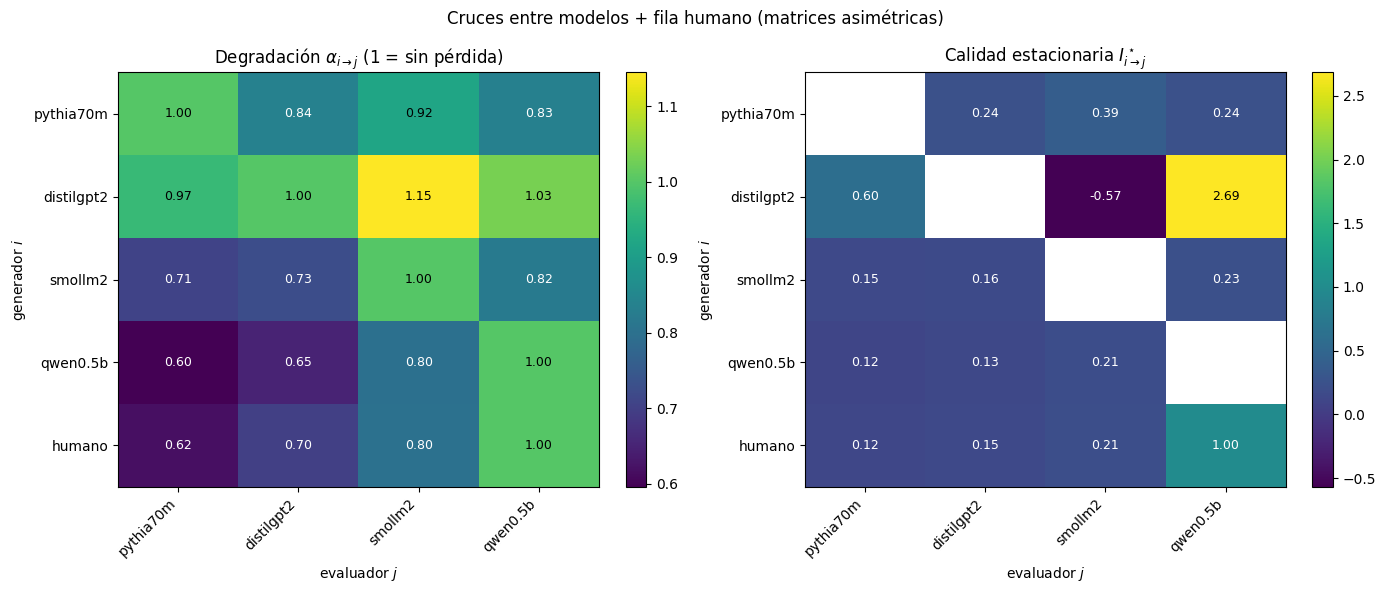

In [ ]:
def heatmap(ax, Mat, titulo, cmap="viridis"):
    im = ax.imshow(Mat, cmap=cmap, vmin=np.nanmin(Mat), vmax=np.nanmax(Mat),
                   aspect="auto")
    ax.set_xticks(range(E)); ax.set_yticks(range(G))
    ax.set_xticklabels(NAMES, rotation=45, ha="right")
    ax.set_yticklabels(GEN_NAMES)
    ax.set_xlabel("evaluador $j$"); ax.set_ylabel("generador $i$")
    ax.set_title(titulo)
    lo, hi = np.nanmin(Mat), np.nanmax(Mat)
    for i in range(G):
        for j in range(E):
            v = Mat[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                        color="white" if v < (lo+hi)/2 else "black", fontsize=9)
    return im

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
im0 = heatmap(axes[0], ALPHA, r"Degradación $\alpha_{i\to j}$ (1 = sin pérdida)")
fig.colorbar(im0, ax=axes[0], fraction=0.046)
im1 = heatmap(axes[1], Istar_mat, r"Calidad estacionaria $I^\star_{i\to j}$")
fig.colorbar(im1, ax=axes[1], fraction=0.046)
fig.suptitle("Cruces entre modelos + fila humano (matrices asimétricas)")
fig.tight_layout()
plt.savefig(out("heatmaps_alpha_Istar.png"), dpi=150, bbox_inches="tight")
plt.show()

### 8.1 Trayectorias dinámicas de todos los cruces
Cada curva es la evolución $I_t$ de un cruce $i\to j$. Las que se estabilizan más arriba preservan
mejor la información.

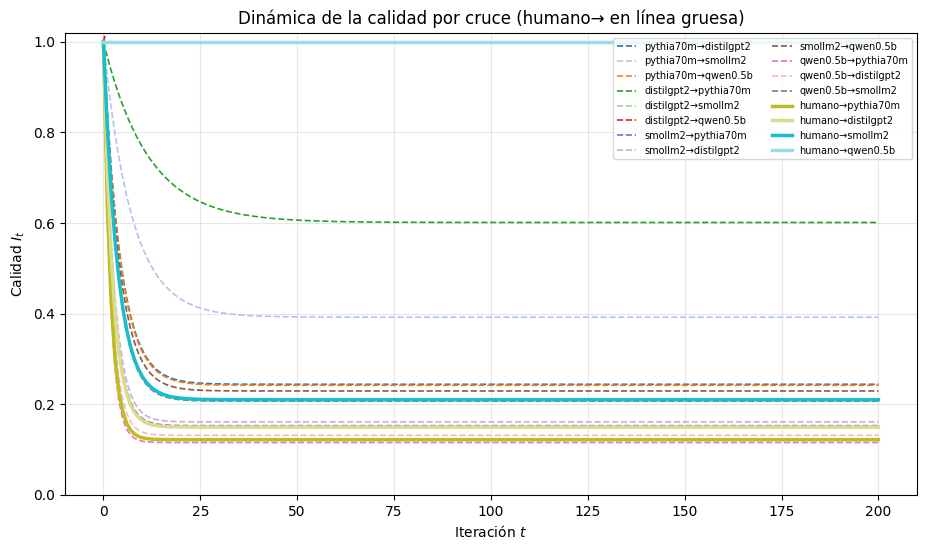

In [ ]:
plt.figure(figsize=(11, 6))
cmap = plt.cm.tab20(np.linspace(0, 1, len(trayectorias)))
for k, ((i, j), I) in enumerate(trayectorias.items()):
    es_humano = (GEN_NAMES[i] == "humano")
    plt.plot(I, color=cmap[k], linewidth=2.5 if es_humano else 1.2,
             linestyle="-" if es_humano else "--",
             label=f"{GEN_NAMES[i]}→{NAMES[j]}")
plt.xlabel("Iteración $t$"); plt.ylabel("Calidad $I_t$"); plt.ylim(0, 1.02)
plt.title("Dinámica de la calidad por cruce (humano→ en línea gruesa)")
plt.legend(ncol=2, fontsize=7, loc="upper right")
plt.grid(True, alpha=0.3)
plt.savefig(out("trayectorias_cruces.png"), dpi=150, bbox_inches="tight")
plt.show()

### 8.3 Trayectorias agrupadas
Una subgráfica por generador (incluido `humano`): muestra cómo le va a *su* texto según quién lo
procese.

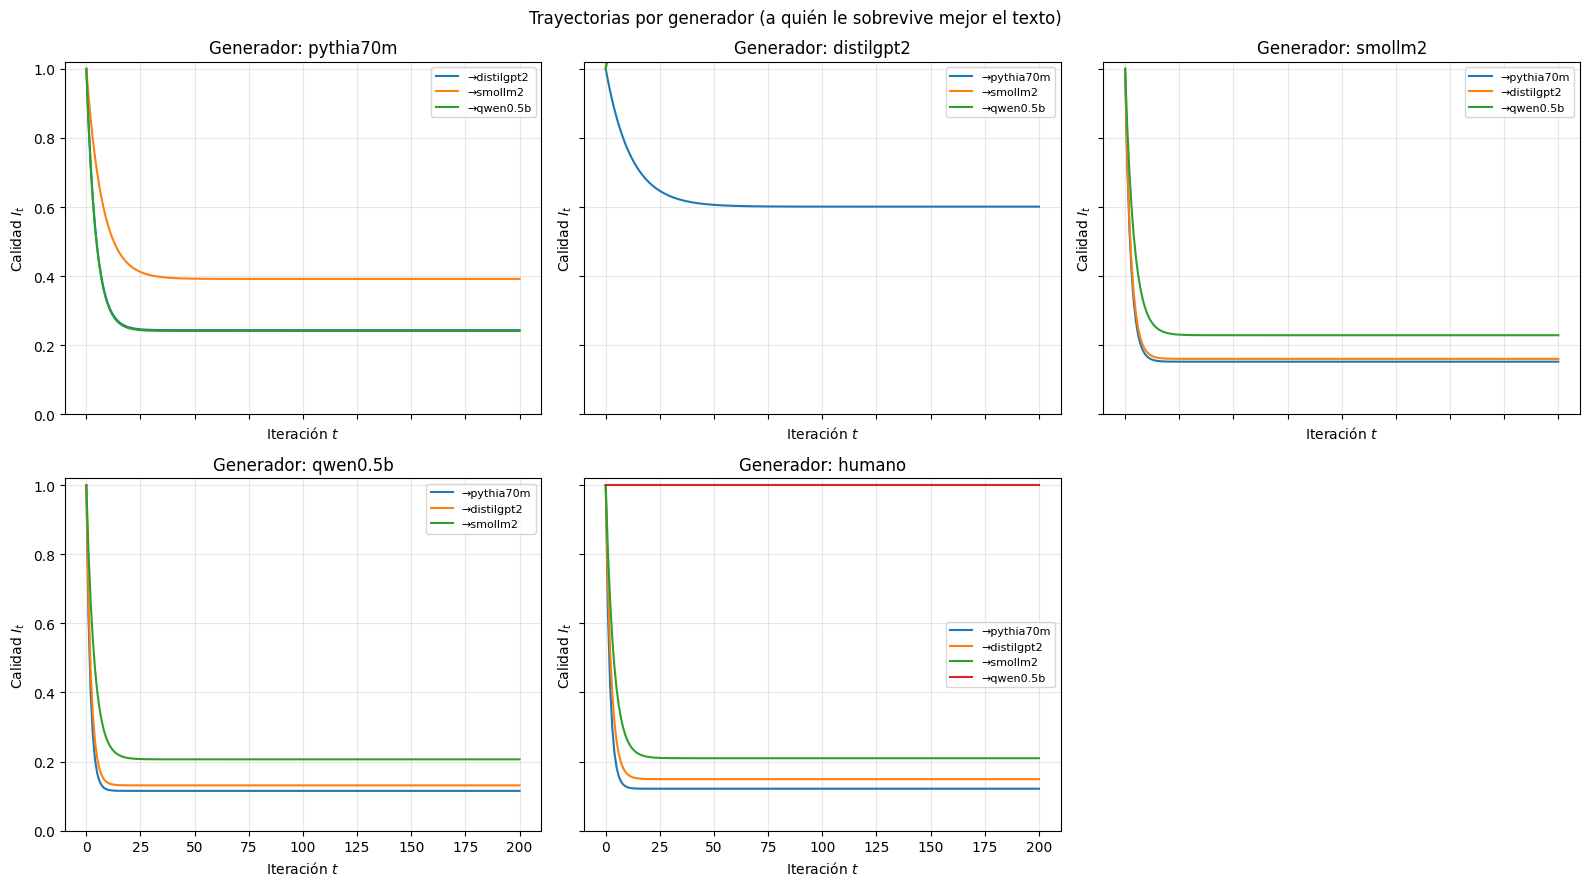

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=True)
for idx, ax in enumerate(axes.flat):
    if idx >= G:
        ax.axis("off"); continue
    gen_name = GEN_NAMES[idx]
    for j in range(E):
        if gen_name == NAMES[j]:
            continue
        ax.plot(trayectorias[(idx, j)], label=f"→{NAMES[j]}")
    ax.set_title(f"Generador: {gen_name}")
    ax.set_ylim(0, 1.02); ax.grid(True, alpha=0.3); ax.legend(fontsize=8)
    ax.set_xlabel("Iteración $t$"); ax.set_ylabel("Calidad $I_t$")
fig.suptitle("Trayectorias por generador (a quién le sobrevive mejor el texto)")
fig.tight_layout()
plt.savefig(out("trayectorias_por_generador.png"), dpi=150, bbox_inches="tight")
plt.show()

### 8.4 Ranking de preservación

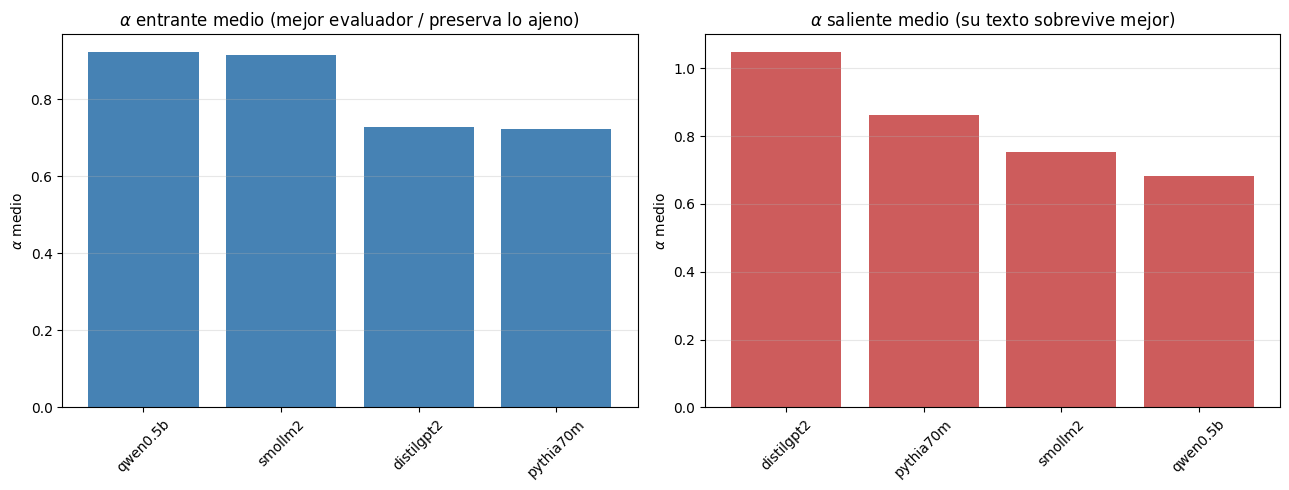

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
order_e = np.argsort(-entrante)
axes[0].bar([NAMES[j] for j in order_e], entrante[order_e], color="steelblue")
axes[0].set_title(r"$\alpha$ entrante medio (mejor evaluador / preserva lo ajeno)")
axes[0].set_ylabel(r"$\alpha$ medio"); axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(True, axis="y", alpha=0.3)

order_s = np.argsort(-saliente)
axes[1].bar([NAMES[i] for i in order_s], saliente[order_s], color="indianred")
axes[1].set_title(r"$\alpha$ saliente medio (su texto sobrevive mejor)")
axes[1].set_ylabel(r"$\alpha$ medio"); axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(True, axis="y", alpha=0.3)
fig.tight_layout()
plt.savefig(out("ranking_preservacion.png"), dpi=150, bbox_inches="tight")
plt.show()

## 9. Dinámica vectorial acoplada con la matriz $W=\alpha$

Hasta aquí tratamos cada cruce por separado. Pero podemos cerrar el círculo con el **modelo vectorial**
del informe, usando la matriz de degradación medida como matriz de mezcla
$W$ (normalizada por filas). La condición de estabilidad del informe era
$(1-h)(1-f)\,\rho(W)<1$. Aquí $\rho$ es el radio espectral de la matriz empírica.

rho(W) = 0.814
(1-h)(1-f)*rho = 0.773  ->  ESTABLE


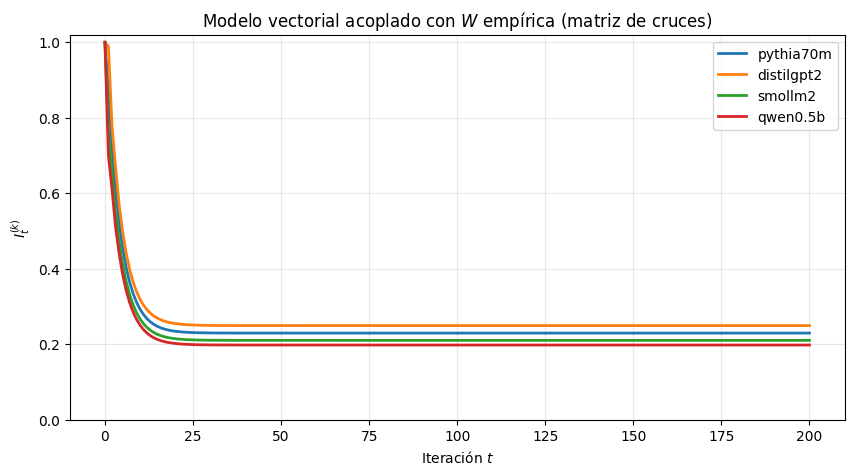


Valores estacionarios por modelo:
  pythia70m   I_inf = 0.230
  distilgpt2  I_inf = 0.249
  smollm2     I_inf = 0.210
  qwen0.5b    I_inf = 0.198


In [ ]:
# Acoplamiento por CRUCES entre modelos.

W = np.clip(ALPHA[:E, :E], 0.0, 1.0).copy()
np.fill_diagonal(W, 0.0)
W = W / (E - 1)

rho = max(abs(np.linalg.eigvals(W)))
cond = (1 - H_HUMAN) * (1 - F_CUR) * rho
print(f"rho(W) = {rho:.3f}")
print(f"(1-h)(1-f)*rho = {cond:.3f}  ->  "
      f"{'ESTABLE' if cond < 1 else 'riesgo de colapso'}")

def sim_vectorial(W, h=H_HUMAN, f=F_CUR, alpha_scale=1.0, T=T_SIM):
    K = W.shape[0]; I = np.zeros((T+1, K)); I[0] = 1.0
    ones = np.ones(K)
    for t in range(T):
        I[t+1] = h*ones + (1-h)*((1-f)*alpha_scale*(W @ I[t]) + f*ones)
    return I

Iv = sim_vectorial(W)
plt.figure(figsize=(10, 5))
for k in range(E):
    plt.plot(Iv[:, k], label=NAMES[k], linewidth=2)
plt.xlabel("Iteración $t$"); plt.ylabel("$I_t^{(k)}$"); plt.ylim(0, 1.02)
plt.title(r"Modelo vectorial acoplado con $W$ empírica (matriz de cruces)")
plt.legend(); plt.grid(True, alpha=0.3)
plt.savefig(out("vectorial_acoplado.png"), dpi=150, bbox_inches="tight")
plt.show()

print("\nValores estacionarios por modelo:")
for k in range(E):
    print(f"  {NAMES[k]:11s} I_inf = {Iv[-1, k]:.3f}")

## 10. Resultados

In [ ]:
import glob, shutil
print("Archivos generados:")
for a in sorted(glob.glob(out("*"))):
    print("  ", os.path.basename(a))
shutil.make_archive("salidas_cruces_llm", "zip", OUTDIR)
print("\nZIP: salidas_cruces_llm.zip")
try:
    from google.colab import files
    files.download("salidas_cruces_llm.zip")
except Exception:
    pass

Archivos generados:
   H_matrix.csv
   Istar_matrix.csv
   alpha_matrix.csv
   heatmaps_alpha_Istar.png
   ranking_preservacion.png
   textos_generados.json
   trayectorias_cruces.png
   trayectorias_por_generador.png
   vectorial_acoplado.png

ZIP: salidas_cruces_llm.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>